In [1]:
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np

In [2]:
df = pd.read_csv('placement (3).csv')

In [3]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [5]:
df.shape

(200, 2)

Text(0, 0.5, 'Package')

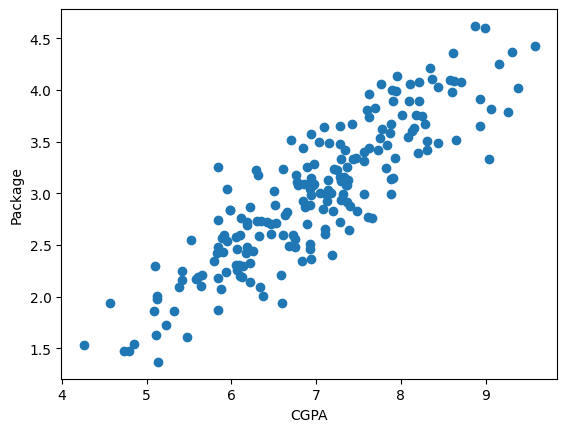

In [6]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package')

In [7]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [8]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [10]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()


In [11]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Text(0, 0.5, 'Package')

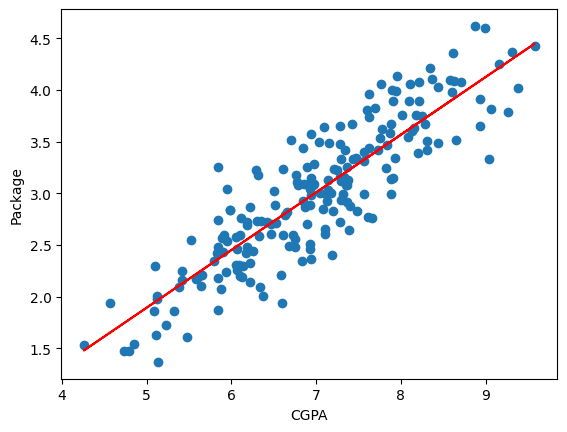

In [12]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package')

In [14]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [15]:
y_pred = lr.predict(X_test)

In [16]:
print('MAE:',mean_absolute_error(y_test,y_pred))

MAE: 0.2884710931878175


In [17]:
print('MSE:',mean_squared_error(y_test,y_pred))

MSE: 0.12129235313495527


In [19]:
print('RMSE',np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE 0.34827051717731616


In [21]:
print('R2 Score:',r2_score(y_test,y_pred))
r2  = r2_score(y_test,y_pred)

R2 Score: 0.780730147510384


In [22]:
X_test.shape

(40, 1)

In [24]:
# Adjusted R2 Score
n=40
Adjuster_R2  = 1 -((1-r2)*(n-1))/(n-1-1)
print('Adjusted R2 Score:',Adjuster_R2)

Adjusted R2 Score: 0.7749598882343415


In [27]:
new_df = df.copy()
new_df['random_feature'] = np.random.random(200)

new_df = new_df[['cgpa','random_feature','package']]
new_df.head()


,cgpa,random_feature,package
0,6.89,0.134694,3.26
1,5.12,0.297985,1.98
2,7.82,0.134548,3.25
3,7.42,0.012950,3.67
4,6.94,0.185758,3.57


Text(0, 0.5, 'Package(in lpa)')

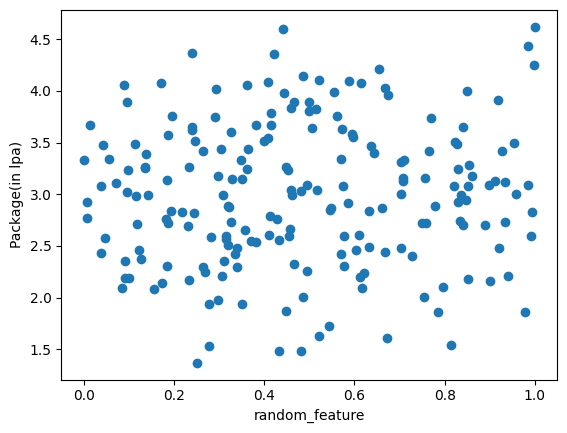

In [29]:

plt.scatter(new_df['random_feature'],new_df['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')

In [30]:
X = new_df.iloc[:,0:2]
y = new_df.iloc[:,-1]


In [31]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [32]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)


In [33]:
print("R2 Score:",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 Score: 0.7807724532562709


In [34]:
1-((1-r2)*(n-1))/(n-2-1)

0.7689223155944477